<a href="https://colab.research.google.com/github/Eugeneiyukhun/Capstone001/blob/main/Supervised_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

# Project: Project: Energy Consumption Forecasting
# --Household Power Consumption
# Project Description
The goal is to build a regression model that predicts energy consumption (in kWh) based on historical usage data and external factors like weather, time of day, and season. The focus is on:

Residential Energy Consumption: Predict usage for a single household or building.

Grid-Level Energy Consumption: Predict usage for an entire region or city.


# Tools and Libraries
Python Libraries:

Pandas, NumPy (data manipulation)

Scikit-learn (regression models)

XGBoost, LightGBM (gradient boosting)

TensorFlow/Keras (LSTM for time-series)

Matplotlib, Seaborn (visualization)


# Workflow
Load Data:

Load energy consumption and weather data.

Preprocess Data: Merge datasets on timestamps.

Handle missing values and outliers.

Feature Engineering:  Create time-based features (e.g., hour of day, day of week).

Add weather features (e.g., temperature, humidity).

Train-Test Split: Split data into training and testing sets (e.g., 80-20 split).

Model Training: Train regression models (e.g., Linear Regression, Random Forest, XGBoost).

Evaluate Models: Compare models using MAE, RMSE, or R².

Visualize Results: Plot actual vs. predicted energy consumption.

# Loading The Data
Step 1: Understand the Dataset
The dataset contains measurements of electric power consumption in one household with a one-minute sampling rate over almost 4 years. It includes the following features:

-Date: Date in format dd/mm/yyyy.

-Time: Time in format hh:mm:ss.

-Global_active_power: Household global minute-averaged active power (in kilowatts).

-Global_reactive_power: Household global minute-averaged reactive power (in kilowatts).

-Voltage: Minute-averaged voltage (in volts).

-Global_intensity: Household global minute-averaged current intensity (in amperes).

-Sub_metering_1: Energy sub-metering for kitchen (in watt-hours).

-Sub_metering_2: Energy sub-metering for laundry (in watt-hours).

-Sub_metering_3: Energy sub-metering for heating/cooling systems (in watt-hours).

In [5]:
df = pd.read_csv('/content/household_power_consumption.txt',delimiter=';')
df.to_csv('household_energy_consumption.csv',index=False)

NameError: name 'pd' is not defined

In [6]:
df= pd.read_csv('/content/household_energy_consumption.csv')
df

NameError: name 'pd' is not defined

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
df = pd.read_csv('/content/household_power_consumption.csv', delimiter=';')
df.head()

<ipython-input-8-d203064483ba>:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/household_power_consumption.csv', delimiter=';')


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [9]:
df.shape

(196984, 9)

# Step 2: Define the Problem
Objective: Predict future energy consumption (e.g., Global_active_power) based on historical data and other features.

Approach:

-Treat this as a time-series regression problem.

-Use past energy consumption and other features (e.g., time of day, sub-metering data) to predict future consumption.

In [10]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

# Step 3: Data Preprocessing
Load the Data:

Use Pandas to load the dataset.

# Handle Missing Values:

In [11]:
# Check for missing values
#clean my data
df.isna().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,1
Sub_metering_2,1
Sub_metering_3,3733


In [12]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Show only columns with missing values
print(missing_values)

Sub_metering_1       1
Sub_metering_2       1
Sub_metering_3    3733
dtype: int64


In [13]:
#to check for the datatype
missing_values.info()

<class 'pandas.core.series.Series'>
Index: 3 entries, Sub_metering_1 to Sub_metering_3
Series name: None
Non-Null Count  Dtype
--------------  -----
3 non-null      int64
dtypes: int64(1)
memory usage: 48.0+ bytes


In [14]:
print(df.dtypes)


Date                      object
Time                      object
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object


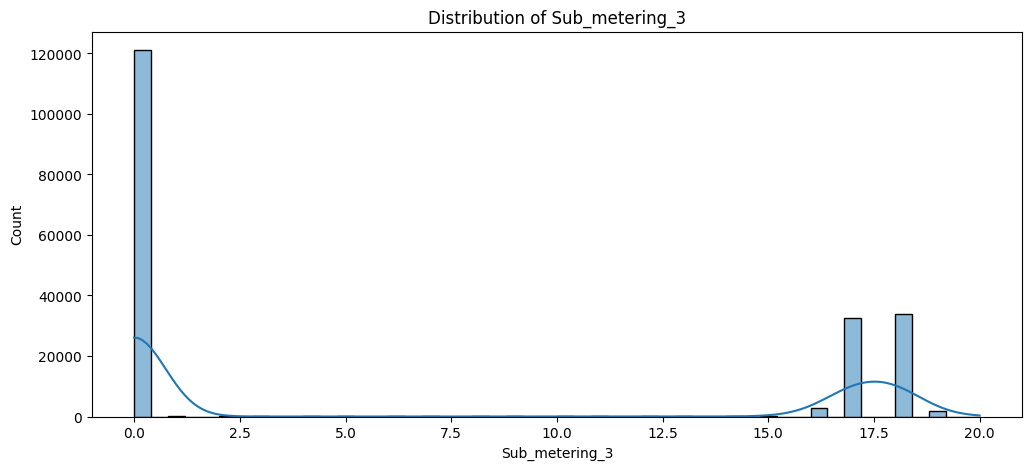

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram to see the distribution
plt.figure(figsize=(12, 5))
sns.histplot(df['Sub_metering_3'], bins=50, kde=True)
plt.title("Distribution of Sub_metering_3")
plt.show()


In [16]:
# To checkforthe subset of the graph
df['Sub_metering_1'].value_counts()

,count
Sub_metering_1,
0.000,177079
1.000,7427
?,3732
2.000,1728
38.000,1723
...,...
59.000,1
60.000,1
47.000,1


In [17]:
# To checkforthe subset of the graph
df['Sub_metering_1'].value_counts()

,count
Sub_metering_1,
0.000,177079
1.000,7427
?,3732
2.000,1728
38.000,1723
...,...
59.000,1
60.000,1
47.000,1


In [18]:
# To checkforthe subset of the graph
df['Sub_metering_3'].value_counts()

,count
Sub_metering_3,
0.0,121114
18.0,33931
17.0,32539
16.0,2871
19.0,1945
15.0,77
9.0,75
4.0,65
1.0,62


In [19]:
df['Sub_metering_1'].value_counts()

,count
Sub_metering_1,
0.000,177079
1.000,7427
?,3732
2.000,1728
38.000,1723
...,...
59.000,1
60.000,1
47.000,1


In [20]:
df['Sub_metering_2'].value_counts()

,count
Sub_metering_2,
0.000,136159
1.000,32108
2.000,14168
?,3732
37.000,1060
...,...
78.000,1
8.0,1
38.0,1


In [21]:
df['Sub_metering_2'].isna()

,Sub_metering_2
0,False
1,False
2,False
3,False
4,False
...,...
196979,False
196980,False
196981,False
196982,False


In [22]:
# Count occurrences of "?"
# Identify "Mischievous Data"
#First, let's check how many question marks exist and in which columns.


print((df == '?').sum())


Date                        0
Time                        0
Global_active_power      3732
Global_reactive_power    3732
Voltage                  3732
Global_intensity         3732
Sub_metering_1           3732
Sub_metering_2           3732
Sub_metering_3              0
dtype: int64


In [23]:
#Convert "?" to NaN
#Pandas reads ? as a string, so replace it with NaN (Not a Number) for proper handling.

import numpy as np

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Check again for missing values
print(df.isnull().sum())


Date                        0
Time                        0
Global_active_power      3732
Global_reactive_power    3732
Voltage                  3732
Global_intensity         3732
Sub_metering_1           3733
Sub_metering_2           3733
Sub_metering_3           3733
dtype: int64


In [24]:
#Determine How to Handle NaN Values
#After replacing ?, check if the affected columns are numerical or categorical.

print(df.dtypes)

Date                      object
Time                      object
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object


In [25]:
df['Sub_metering_3'].dtype

dtype('float64')

In [26]:
print(df.isnull().sum())  # Should return 0 if everything is cleaned


Date                        0
Time                        0
Global_active_power      3732
Global_reactive_power    3732
Voltage                  3732
Global_intensity         3732
Sub_metering_1           3733
Sub_metering_2           3733
Sub_metering_3           3733
dtype: int64


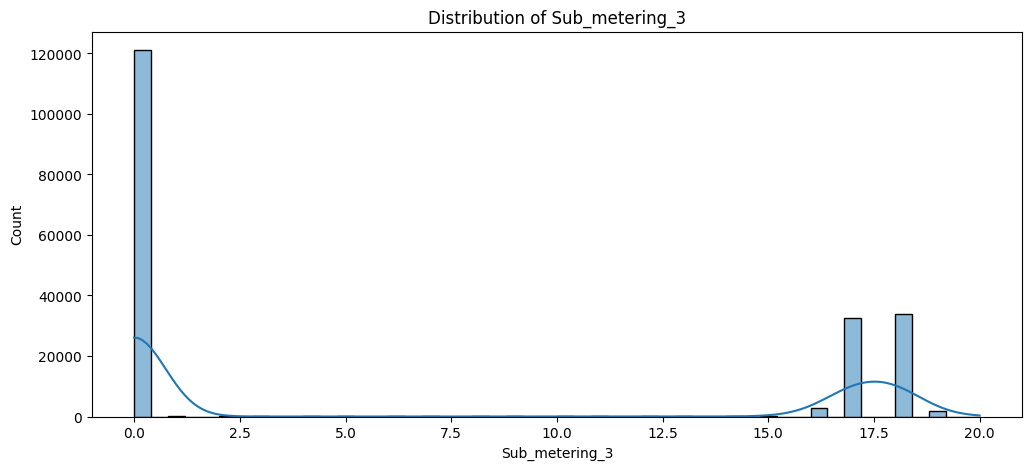

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram to see the distribution
plt.figure(figsize=(12, 5))
sns.histplot(df['Sub_metering_3'], bins=50, kde=True)
plt.title("Distribution of Sub_metering_3")
plt.show()

In [29]:
# This is to calculate for the percentage of the missing values
# Calculate percentage of missing values per column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Display columns with missing values and their percentage
print(missing_percentage[missing_percentage > 0])


Global_active_power      1.894570
Global_reactive_power    1.894570
Voltage                  1.894570
Global_intensity         1.894570
Sub_metering_1           1.895078
Sub_metering_2           1.895078
Sub_metering_3           1.895078
dtype: float64


In [30]:
df_cleaned = df.dropna()


In [31]:
#Toconfirm if there is still a missing value
print(df_cleaned.isnull().sum())


Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [32]:
df.shape, df_cleaned.shape

((196984, 9), (193251, 9))

In [33]:
#To save the csv file or to download
#first save the dataset
df_cleaned.to_csv("actual_dataset.csv", index=False)


In [34]:
#then resave the dataset with anew name
new_df = pd.read_csv('/content/actual_dataset.csv')

In [35]:
#call the newly saved dataset
new_df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...,...
193246,2/5/2007,12:22:00,2.512,0.348,232.55,10.8,0.0,37.0,0.0
193247,2/5/2007,12:23:00,2.332,0.000,232.67,10.0,0.0,37.0,0.0
193248,2/5/2007,12:24:00,1.560,0.000,233.11,8.0,0.0,25.0,0.0
193249,2/5/2007,12:25:00,0.190,0.000,234.82,0.8,0.0,1.0,0.0


In [36]:
#parse date and time
import pandas as pd
new_df = pd.read_csv('/content/actual_dataset.csv', parse_dates={'DateTime': ['Date', 'Time']}, infer_datetime_format=True, low_memory=False)
new_df

<ipython-input-36-b6e1d8ffaff6>:3: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  new_df = pd.read_csv('/content/actual_dataset.csv', parse_dates={'DateTime': ['Date', 'Time']}, infer_datetime_format=True, low_memory=False)
<ipython-input-36-b6e1d8ffaff6>:3: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  new_df = pd.read_csv('/content/actual_dataset.csv', parse_dates={'DateTime': ['Date', 'Time']}, infer_datetime_format=True, low_memory=False)
<ipython-input-36-b6e1d8ffaff6>:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  new_df 

,DateTime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...
193246,2007-05-02 12:22:00,2.512,0.348,232.55,10.8,0.0,37.0,0.0
193247,2007-05-02 12:23:00,2.332,0.000,232.67,10.0,0.0,37.0,0.0
193248,2007-05-02 12:24:00,1.560,0.000,233.11,8.0,0.0,25.0,0.0
193249,2007-05-02 12:25:00,0.190,0.000,234.82,0.8,0.0,1.0,0.0


In [37]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193251 entries, 0 to 193250
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   DateTime               193251 non-null  datetime64[ns]
 1   Global_active_power    193251 non-null  float64       
 2   Global_reactive_power  193251 non-null  float64       
 3   Voltage                193251 non-null  float64       
 4   Global_intensity       193251 non-null  float64       
 5   Sub_metering_1         193251 non-null  float64       
 6   Sub_metering_2         193251 non-null  float64       
 7   Sub_metering_3         193251 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 11.8 MB


In [38]:
import pandas as pd
import numpy as np

In [39]:
new_df = pd.read_csv('/content/actual_dataset.csv', parse_dates={'DateTime': ['Date', 'Time']}, infer_datetime_format=True, low_memory=False)
new_df

<ipython-input-39-b6d8241796ca>:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  new_df = pd.read_csv('/content/actual_dataset.csv', parse_dates={'DateTime': ['Date', 'Time']}, infer_datetime_format=True, low_memory=False)
<ipython-input-39-b6d8241796ca>:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  new_df = pd.read_csv('/content/actual_dataset.csv', parse_dates={'DateTime': ['Date', 'Time']}, infer_datetime_format=True, low_memory=False)
<ipython-input-39-b6d8241796ca>:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  new_df 

,DateTime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...
193246,2007-05-02 12:22:00,2.512,0.348,232.55,10.8,0.0,37.0,0.0
193247,2007-05-02 12:23:00,2.332,0.000,232.67,10.0,0.0,37.0,0.0
193248,2007-05-02 12:24:00,1.560,0.000,233.11,8.0,0.0,25.0,0.0
193249,2007-05-02 12:25:00,0.190,0.000,234.82,0.8,0.0,1.0,0.0


# 3. Feature Engineering:
Extract useful features from the DateTime column:
Create lag features (e.g., energy consumption from the previous hour):

In [40]:
# Ensure the DateTime column is in datetime format
new_df['DateTime'] = pd.to_datetime(new_df['DateTime'])

# Extract date and time features
new_df['Year'] = new_df['DateTime'].dt.year
new_df['Month'] = new_df['DateTime'].dt.month
new_df['Day'] = new_df['DateTime'].dt.day
new_df['Hour'] = new_df['DateTime'].dt.hour
new_df['Minute'] = new_df['DateTime'].dt.minute
new_df['Second'] = new_df['DateTime'].dt.second


In [41]:
import pandas as pd
import numpy as np

# Handle missing or invalid values
new_df['DateTime'].replace('?', np.nan, inplace=True)
new_df.dropna(subset=['DateTime'], inplace=True)

# Ensure DateTime is parsed correctly
new_df['DateTime'] = pd.to_datetime(new_df['DateTime'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
new_df.dropna(subset=['DateTime'], inplace=True)

# Extract date and time features
new_df['Year'] = new_df['DateTime'].dt.year
new_df['Month'] = new_df['DateTime'].dt.month
new_df['Day'] = new_df['DateTime'].dt.day
new_df['Hour'] = new_df['DateTime'].dt.hour
new_df['Minute'] = new_df['DateTime'].dt.minute
new_df['Second'] = new_df['DateTime'].dt.second
new_df['Weekday'] = new_df['DateTime'].dt.weekday

# Extract weekend indicator
new_df['IsWeekend'] = new_df['Weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Extract time of day
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

new_df['TimeOfDay'] = new_df['Hour'].apply(get_time_of_day)

# Extract season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

new_df['Season'] = new_df['Month'].apply(get_season)

# Check the final dataset
print(new_df.head())


             DateTime  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                5.360                  0.436   233.63   
2 2006-12-16 17:26:00                5.374                  0.498   233.29   
3 2006-12-16 17:27:00                5.388                  0.502   233.74   
4 2006-12-16 17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  Year  \
0              18.4             0.0             1.0            17.0  2006   
1              23.0             0.0             1.0            16.0  2006   
2              23.0             0.0             2.0            17.0  2006   
3              23.0             0.0             1.0            17.0  2006   
4              15.8             0.0             1.0            17.0  2006   

   Month  Day  Hour  Minute  Second  Weekday  IsWeekend TimeOfDay  S

# Normalize/Scale Data:

Use MinMaxScaler or StandardScaler to normalize the data.


In [42]:
#Then Normalize/Scale Data:
 #Step 1: Choose a Normalization Method
#Two common normalization techniques:

#Min-Max Scaling (Recommended for most cases)

#Scales data between 0 and 1

#Use when features have different ranges.
#Z-score Standardization (For Normally Distributed Data)

#Centers data around mean = 0 and std = 1

#Use when data follows a normal (bell curve) distribution.





import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler





In [43]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Select numeric columns for scaling
numeric_cols = new_df.select_dtypes(include=['int64', 'float64']).columns  # Automatically detects numerical columns

# Fit and transform the data
new_df[numeric_cols] = scaler.fit_transform(new_df[numeric_cols])

# Check the scaled data
print(new_df.head())


             DateTime  Global_active_power  Global_reactive_power   Voltage  \
0 2006-12-16 17:24:00             0.389173               0.478261  0.402340   
1 2006-12-16 17:25:00             0.497445               0.498856  0.359447   
2 2006-12-16 17:26:00             0.498770               0.569794  0.347395   
3 2006-12-16 17:27:00             0.500095               0.574371  0.363346   
4 2006-12-16 17:28:00             0.337119               0.604119  0.432116   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  Year  \
0          0.391304             0.0        0.012821            0.85  2006   
1          0.491304             0.0        0.012821            0.80  2006   
2          0.491304             0.0        0.025641            0.85  2006   
3          0.491304             0.0        0.012821            0.85  2006   
4          0.334783             0.0        0.012821            0.85  2006   

   Month  Day  Hour  Minute  Second  Weekday  IsWeekend TimeOf

In [44]:
#Check correlations between features and the target variable (Global_active_power).
import matplotlib.pyplot as plt  # Import Matplotlib
import seaborn as sns


# Step 4: Exploratory Data Analysis (EDA)
Visualize Energy Consumption Over Time:

-Plot Global_active_power over time to identify trends and seasonality.
-Correlation Analysis:

-Check correlations between features and the target variable (Global_active_power).

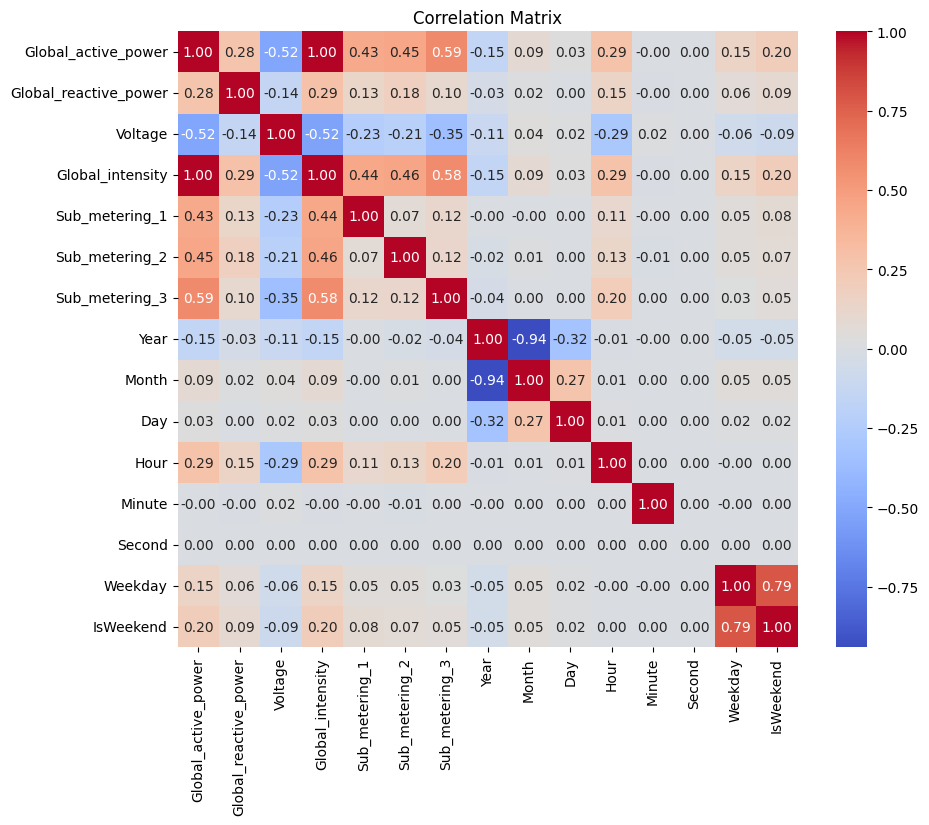

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the correlation matrix only for numeric columns
correlation_matrix = new_df.select_dtypes(include=['number']).corr()

# Handle missing values (if any)
correlation_matrix = correlation_matrix.fillna(0)

# Set figure size
plt.figure(figsize=(10, 8))

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Add title and show the plot
plt.title('Correlation Matrix')
plt.show()



# Step 5: Model Building
Train-Test Split:

Split the data into training and testing sets (e.g., 80-20 split).

In [55]:
from sklearn.model_selection import train_test_split

# new_df is the dataframe
X = new_df.drop('Global_active_power', axis=1)
y = new_df['Global_active_power']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [62]:
print(new_df.columns)  # Check if 'Global_active_power' exists
print(new_df.dtypes)   # Ensure it's a numeric column


Index(['DateTime', 'Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second',
       'Weekday', 'IsWeekend', 'TimeOfDay', 'Season'],
      dtype='object')
DateTime                 datetime64[ns]
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
Year                              int32
Month                             int32
Day                               int32
Hour                              int32
Minute                            int32
Second                            int32
Weekday                           int32
IsWeekend                       float64
TimeOfDay                        object
Season                   

# Model Selection:

Start with simple models like Linear Regression, then move to advanced models:

Random Forest

XGBoost

LSTM (for time-series forecasting)

# Clean and Train
Start with your preprocessed DataFrame

In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Example: make sure new_df exists
print(new_df.head())
print(new_df.dtypes)


   Global_active_power  Global_reactive_power   Voltage  Global_intensity  \
0             0.389173               0.478261  0.402340          0.391304   
1             0.497445               0.498856  0.359447          0.491304   
2             0.498770               0.569794  0.347395          0.491304   
3             0.500095               0.574371  0.363346          0.491304   
4             0.337119               0.604119  0.432116          0.334783   

   Sub_metering_1  Sub_metering_2  Sub_metering_3  Year  Month  Day  Hour  \
0             0.0        0.012821            0.85  2006     12   16    17   
1             0.0        0.012821            0.80  2006     12   16    17   
2             0.0        0.025641            0.85  2006     12   16    17   
3             0.0        0.012821            0.85  2006     12   16    17   
4             0.0        0.012821            0.85  2006     12   16    17   

   Minute  Second  Weekday  IsWeekend TimeOfDay  Season  
0      24       

#Drop non-numeric columns "DateTime"

In [75]:
# Check if 'DateTime' exists and drop it
if 'DateTime' in new_df.columns:
    new_df = new_df.drop(columns=['DateTime'])


Checking if there is no object or datetime types remain

In [76]:
print(new_df.dtypes)  # All should be float or int


Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
Year                       int32
Month                      int32
Day                        int32
Hour                       int32
Minute                     int32
Second                     int32
Weekday                    int32
IsWeekend                float64
TimeOfDay                 object
Season                    object
dtype: object


# Split into features and target

In [77]:
X = new_df.drop(columns=['Global_active_power'])
y = new_df['Global_active_power']


# Train-test split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [80]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

#Remove Date and Time

In [83]:
if 'DateTime' in X_train.columns:
    X_train = X_train.drop(columns=['DateTime'])
    X_test = X_test.drop(columns=['DateTime'])


In [85]:
X = new_df.drop(columns=['Global_active_power'])
y = new_df['Global_active_power']


In [84]:
print(new_df.dtypes)  # All should be float or int


Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
Year                       int32
Month                      int32
Day                        int32
Hour                       int32
Minute                     int32
Second                     int32
Weekday                    int32
IsWeekend                float64
TimeOfDay                 object
Season                    object
dtype: object


# Train the model

In [87]:
# Remove non-numeric columns if any
X_train = X_train.select_dtypes(include=['number'])

# Remove NaNs
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

# Fit model again
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)




RandomForestRegressor(random_state=42)

In [92]:
print(X_train.columns)
print(X_test.columns)


Index(['Global_reactive_power', 'Voltage', 'Global_intensity',
       'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Year', 'Month',
       'Day', 'Hour', 'Minute', 'Second', 'Weekday', 'IsWeekend'],
      dtype='object')
Index(['Global_reactive_power', 'Voltage', 'Global_intensity',
       'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Year', 'Month',
       'Day', 'Hour', 'Minute', 'Second', 'Weekday', 'IsWeekend', 'TimeOfDay',
       'Season'],
      dtype='object')


In [93]:
X_test = X_test[X_train.columns]


In [94]:
print(X_test.dtypes)
print(X_test.isnull().sum())


Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
Year                       int32
Month                      int32
Day                        int32
Hour                       int32
Minute                     int32
Second                     int32
Weekday                    int32
IsWeekend                float64
dtype: object
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Year                     0
Month                    0
Day                      0
Hour                     0
Minute                   0
Second                   0
Weekday                  0
IsWeekend                0
dtype: int64


In [95]:
X_test = X_test.select_dtypes(include=['number'])
X_test = X_test.dropna()


In [96]:
# Align features
X_test = X_test[X_train.columns]

# Ensure no missing values
X_test = X_test.dropna()

# Predict
y_pred = model.predict(X_test)


In [97]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


# Define features (X) and target (y)
X = new_df.drop('Global_active_power', axis=1)
y = new_df['Global_active_power']

# Perform one-hot encoding on categorical columns
X = pd.get_dummies(X, columns=['TimeOfDay', 'Season'], drop_first=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(X_train.dtypes)
print(y_train.dtypes)


Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
Year                       int32
Month                      int32
Day                        int32
Hour                       int32
Minute                     int32
Second                     int32
Weekday                    int32
IsWeekend                float64
TimeOfDay_Evening           bool
TimeOfDay_Morning           bool
TimeOfDay_Night             bool
Season_Winter               bool
dtype: object
float64


# Step 6: Model Evaluation
Predict on Test Data:

# Evaluate Performance:

Use metrics like Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

Version check

In [98]:
import sklearn
print(sklearn.__version__)  # Should be 0.22 or later


1.6.1


Update version

In [99]:
!pip install --upgrade scikit-learn


Evaluate Performance:

Use metrics like Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)
print(f'MAE: {mae}, RMSE: {rmse}, R²: {r2}')


MAE: 0.0026855564307559595, RMSE: 0.004265202476279172, R²: 0.9977143074996605


# Visualize Predictions:

Plot actual vs. predicted energy consumption.

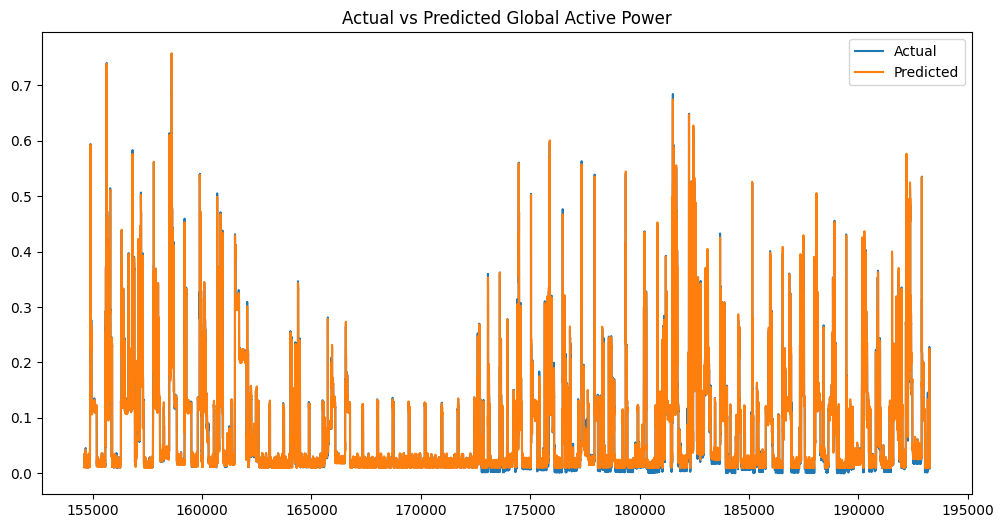

In [101]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Global Active Power')
plt.show()

In [102]:
print(X_train.dtypes)


Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
Year                       int32
Month                      int32
Day                        int32
Hour                       int32
Minute                     int32
Second                     int32
Weekday                    int32
IsWeekend                float64
TimeOfDay_Evening           bool
TimeOfDay_Morning           bool
TimeOfDay_Night             bool
Season_Winter               bool
dtype: object


In [103]:
print(new_df.columns)


Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second',
       'Weekday', 'IsWeekend', 'TimeOfDay', 'Season'],
      dtype='object')
